In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import bpmeth
import sympy as sp

Define multipole coefficients in a curved frame, then build $\vec{A}$, H and track.

curvature h[m^-1]:  1 radius of curvature [m]:  1.0
E [GeV]:  1.03827208816
beta0:  0.42819548497881543


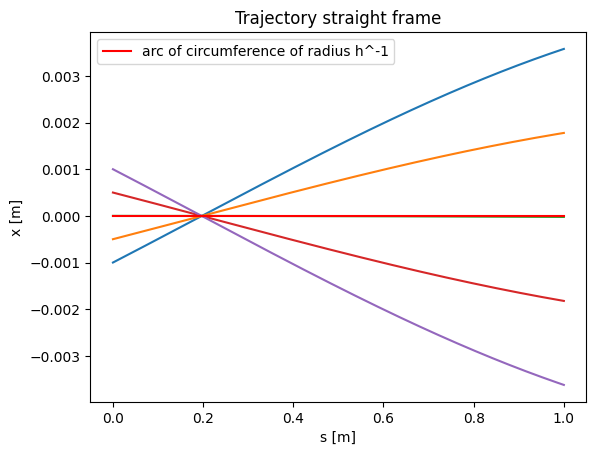

In [2]:
a_curved = [0,]
b_curved = [1,0.2]
h= b_curved[0]# considering normalization B/Brho=1/rho=h
print("curvature h[m^-1]: ", h, "radius of curvature [m]: ", 1/h)
#I want to track protons of given kinetic energy
Ek=1e8 #eV
p=np.sqrt(Ek**2+2*Ek*xt.PROTON_MASS_EV)#momentum eV/c
Eref = Ek + xt.PROTON_MASS_EV
print("E [GeV]: ", Eref/1e9)
gamma0 = Eref/xt.PROTON_MASS_EV
beta0 = np.sqrt(1-1/gamma0**2)
print("beta0: ", beta0)
p0 =xt.Particles(x=np.linspace(-1e-3, 1e-3, 5), y=0, s=0,py=0.01, px=np.linspace(0.005,-0.005,5), ptau=0, beta0=beta0, energy0=Eref, mass0=xt.PROTON_MASS_EV)
p_1 = p0.copy()

A_curved= bpmeth.GeneralVectorPotential(h=h, b=b_curved, a=a_curved)
H_curved = bpmeth.Hamiltonian(length=1, h=h, vectp=A_curved)

sol_curved = H_curved.track(p_1, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})

for ss in sol_curved:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Trajectory straight frame")
x=np.linspace(0,1,50)
y= np.zeros_like(x)
plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
plt.legend()
plt.show()

Then work at the level of the scalar potential because being a scalar is invariant under change of frame (only the coordinates change). Because of this we can move to the straight frame and perform a harmonic analysis, chacking how the a,b coefficients look in that frame.

In [3]:
expansion_curved = bpmeth.FieldExpansion(a=a_curved, b=b_curved, h=h, nphi=7)
phi_curved = expansion_curved.get_phi()
print("phi curved frame: ", phi_curved)
#transform the scalar potential to curved frame using coordinate transformations
#xcurved =sqrt((x+rho)**2+s**2)-rho       scurved=rho*arctan(s/(x+rho))   with rho=1/h
x, y, s = sp.symbols('x y s', real=True)
xtmp, stmp = sp.symbols("xtmp stmp", real=True)
# rename the curved coordinates temporarily
phi_tmp = phi_curved.xreplace({
    x: xtmp,
    s: stmp
})
# substitute curved -> straight
phi_straight = phi_tmp.xreplace({
    xtmp: sp.sqrt((x + 1/h)**2 + s**2) - 1/h,
    stmp: 1/h * sp.atan(s/(x + 1/h))
})
print("\nphi straight frame: ", phi_straight)

Bxstraight_ana = -phi_straight.diff(x)
Bystraight_ana = -phi_straight.diff(y)
Bsstraight_ana = -phi_straight.diff(s)
print("\nBx straight frame: ", Bxstraight_ana)

phi curved frame:  -y**5*(0.2*x + 0.2)/(120*(1.0*x**4 + 4.0*x**3 + 6.0*x**2 + 4.0*x + 1.0)) + y**3*(0.2*x + 0.2)/(6*(1.0*x + 1)**2) - y*(0.2*x + 1)

phi straight frame:  -0.00166666666666667*y**5*sqrt(s**2 + (x + 1.0)**2)/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0) + 0.0333333333333333*y**3/sqrt(s**2 + (x + 1.0)**2) - y*(0.2*sqrt(s**2 + (x + 1.0)**2) + 0.8)

Bx straight frame:  0.00166666666666667*y**5*sqrt(s**2 + (x + 1.0)**2)*(-4.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)/sqrt(s**2 + (x + 1.0)**2) - 4.0*(x + 1.0)/sqrt(s**2 + (x + 1.0)**2))/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0)

<lambdifygenerated-20>:2: RuntimeWarning: invalid value encountered in divide
  return 0.00166666666666667*y**5*sqrt(s**2 + (x + 1.0)**2)*(-4.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)/sqrt(s**2 + (x + 1.0)**2) - 4.0*(x + 1.0)/sqrt(s**2 + (x + 1.0)**2))/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0)**2 + 0.00166666666666667*y**5*(x + 1.0)/(sqrt(s**2 + (x + 1.0)**2)*(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0)) - 0.0333333333333333*y**3*(-x - 1.0)/(s**2 + (x + 1.0)**2)**(3/2) + 0.2*y*(x + 1.0)/sqrt(s**2 + (x + 1.0)**2)
<lambdifygenerated-21>:2: RuntimeWarning: invalid value encountered in 

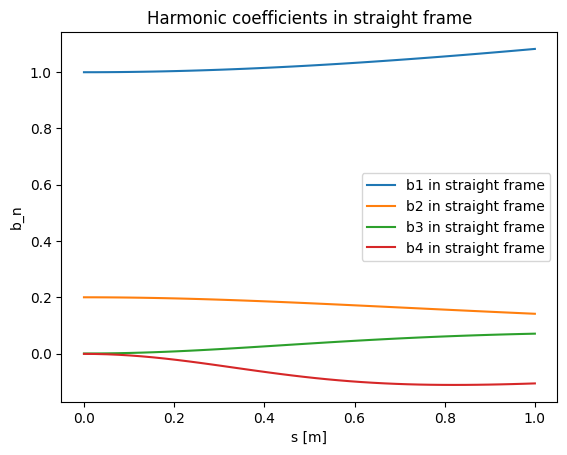

In [4]:
#evaluate fields on cartesian grid 
xstraightarray = np.linspace(-1,1,100)
ystraightarray = np.linspace(-1,1,100)
ns=40
sstraightarray = np.linspace(0,1,ns)
Xstraight, Ystraight, Sstraight = np.meshgrid(xstraightarray, ystraightarray, sstraightarray, indexing='ij')
Bxstraight_ana_array = sp.lambdify((x,y,s), Bxstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight)
Bystraight_ana_array = sp.lambdify((x,y,s), Bystraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight)
Bsstraight_ana_array = sp.lambdify((x,y,s), Bsstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight)
#make a fieldmap object from the field arrays
datastraightfm = np.column_stack((Xstraight.flatten(), Ystraight.flatten(), Sstraight.flatten(), Bxstraight_ana_array.flatten(), Bystraight_ana_array.flatten(), Bsstraight_ana_array.flatten()))
#fm_straight = bpmeth.fieldmaps.Fieldmap(datastraightfm)
#before making the HA sample the field on a cylindrical grid
ntheta=128
nr=40
def interp_cartesian_to_cylindrical(cart_fieldmap, x_1d, y_1d, s_1d, rmin=0.001, rmax=0.4, nr=128,ntheta=256, ns=40):
    """
    Convert Cartesian fieldmap to cylindrical 
    Parameters
    ----------
    cart_fieldmap : ndarray, shape (N, 6)
        Fieldmap in Cartesian: [x, y, s, Bx, By, Bs]
    x_1d, y_1d, s_1d : 1D arrays
        Coordinate arrays from Cartesian grid
    rmin, rmax, nr : float, int
        Cylindrical radial range and resolution
    ntheta : int
        Azimuthal resolution
    ns : int
        Longitudinal resolution
    Returns
    -------
    fields: list
        list containing Bx, By, Bs
    rr : ndarray
        Radial coordinate array
    s_cyl : ndarray
        Cylindrical s coordinate array
    """
    # Resample Cartesian data onto cylindrical grid
    rr = np.linspace(rmin, rmax, nr)
    theta_1d = np.linspace(0.0, 2*np.pi, ntheta, endpoint=False)
    s_cyl = s_1d
    
    R, TH, S = np.meshgrid(rr, theta_1d, s_cyl, indexing='ij')
    
    # Convert to Cartesian for interpolation
    X_query = R * np.cos(TH)
    Y_query = R * np.sin(TH)
    
    # Reshape for interpolation
    shape_src = (len(x_1d), len(y_1d), len(s_1d))
    query_pts = np.column_stack([
        X_query.ravel(),
        Y_query.ravel(),
        S.ravel(),
    ])
    # Interpolate field components
    from scipy.interpolate import RegularGridInterpolator
    
    fields = {}
    for i, name in enumerate(['Bx', 'By', 'Bs']):
        F_3d = cart_fieldmap[:, 3 + i].reshape(shape_src)
        interp = RegularGridInterpolator(
            points=(x_1d, y_1d, s_1d), values=F_3d,
            method='linear', bounds_error=False, fill_value=np.nan,
        )
        fields[name] = interp(query_pts).reshape(nr, ntheta, ns)
    
    return rr, theta_1d, fields
rr, theta_1d, cylfieldatadict= interp_cartesian_to_cylindrical(datastraightfm, x_1d=xstraightarray, y_1d=ystraightarray, s_1d=sstraightarray, rmin=0.001, rmax=0.5, nr=nr, ntheta=ntheta, ns=ns)
rarr, tarr, sarr = np.meshgrid(rr, theta_1d, sstraightarray, indexing='ij')
cylfieldmapdatastack= np.column_stack([rarr.ravel(), tarr.ravel(), sarr.ravel(), cylfieldatadict['Bx'].ravel(), cylfieldatadict['By'].ravel(), cylfieldatadict['Bs'].ravel()])
fm_straight_cyl= bpmeth.fieldmaps.Fieldmap(cylfieldmapdatastack)
svals, astraightofs, bstraightofs, erroras, errorbs = fm_straight_cyl.s_harmonics(rr=rr, ntheta=ntheta, ns=ns, order=4)
plt.plot(svals, bstraightofs[:,0], label='b1 in straight frame')
plt.plot(svals, bstraightofs[:,1], label='b2 in straight frame')
plt.plot(svals, bstraightofs[:,2], label='b3 in straight frame')
plt.plot(svals, bstraightofs[:,3], label='b4 in straight frame')
plt.xlabel('s [m]')
plt.ylabel('b_n')
plt.title('Harmonic coefficients in straight frame')
plt.legend()
plt.show()

As expected an s dependence appeared. To asses the importance of not neglecting it we can see what are the predictions of a naive tracking that would disregard the effect of curvature compared with a more advanced one. 

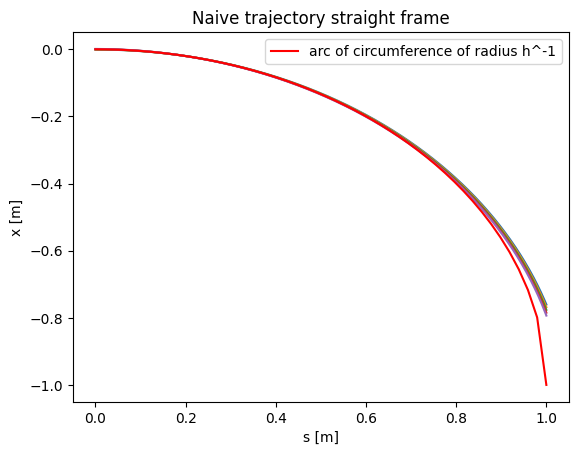

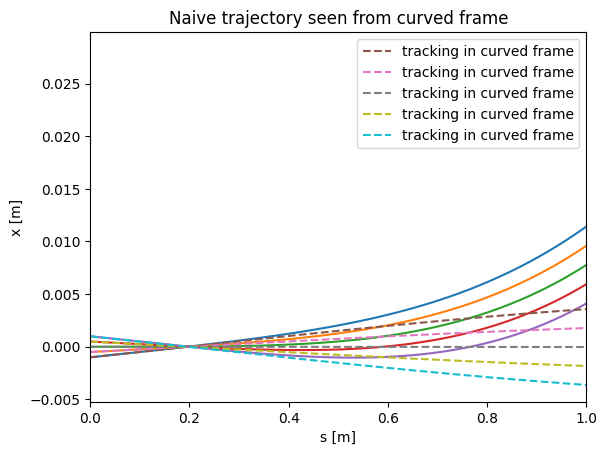

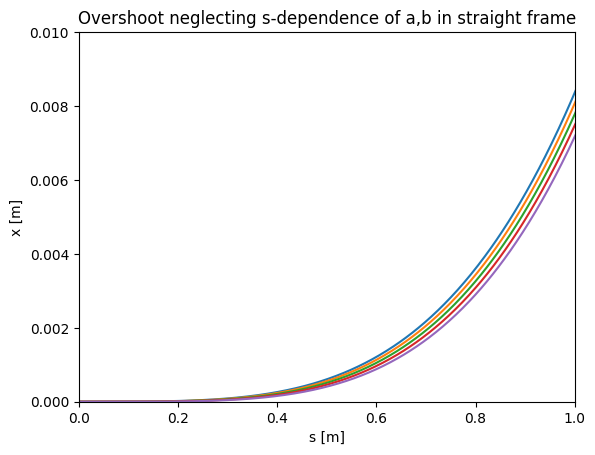

In [25]:
Astrnaive=bpmeth.GeneralVectorPotential(h=0, b=b_curved, a=a_curved)#uses the original simple coefficients disregarding the curvature
Hstrnaive = bpmeth.Hamiltonian(length=1,h=0, vectp=Astrnaive)
p_2 = p0.copy()
sol_strnaive = Hstrnaive.track(p_2, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
for ss in sol_strnaive:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Naive trajectory straight frame")
x=np.linspace(0,1,50)
y= -1/h +np.sqrt(h**-2 -x**2)
plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
plt.legend()
plt.show()

#visualise from the pov of the curved frame
for ss in sol_strnaive:
    xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
    sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
    plt.plot(sc,xc)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Naive trajectory seen from curved frame")
# x=np.linspace(0,1,50)
# y= np.zeros(50)
# plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
for ss in sol_curved:
    plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
plt.legend()
plt.xlim((0., 1.))#because H curved has length 1
plt.show()
for (sn, sa) in zip(sol_strnaive,sol_curved):
    xc=np.sqrt((sn.y[0]+1/h)**2+sn.t**2)-1/h
    sc=np.arctan(sn.t/(sn.y[0]+1/h))/h 
    xa=sa.y[0]
    deltax=xc-xa
    plt.plot(sc,deltax)
plt.xlabel('s [m]')   
plt.ylabel('x [m]')
plt.xlim((0.,1.))
plt.ylim((0.,0.01))
plt.title('Overshoot neglecting s-dependence of a,b in straight frame')
plt.show()


If we want to be a bit more precise we can stay in the straight frame but account for the s dependence of the coefficients

(40, 4) (40, 4)


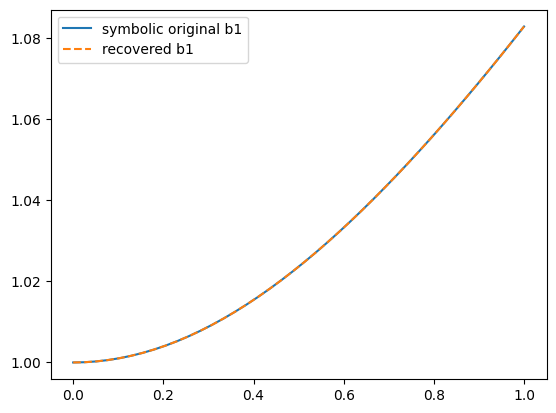

In [29]:
# Better-conditioned symbolic fit for the recovered a,b coefficients
# Use a Chebyshev basis on [0,1] and a moderate degree to reduce ill-conditioning.
degree = 10
b_nfit = []
a_nfit = []
print(bstraightofs.shape, astraightofs.shape)

s = sp.symbols('s')

for arr, dst in [(bstraightofs, b_nfit), (astraightofs, a_nfit)]:
    for j in range(arr.shape[1]):
        cheb = np.polynomial.Chebyshev.fit(sstraightarray, arr[:, j], deg=degree, domain=[0, 1])
        poly = cheb.convert(kind=np.polynomial.Polynomial)
        coeffs = poly.coef
        poly_expr = sum(sp.Float(coeffs[i]) * s**i for i in range(len(coeffs)))
        dst.append(str(sp.expand(poly_expr)))

from sympy import lambdify
plt.plot(sstraightarray, bstraightofs[:,0], label="symbolic original b1")
b1ofslambdified = lambdify(s, b_nfit[0], modules='numpy')
plt.plot(sstraightarray, b1ofslambdified(sstraightarray),'--', label='recovered b1')
plt.legend()
plt.show()


In [ ]:
Astrbetter=bpmeth.GeneralVectorPotential(h=0, b=b_nfit, a=a_nfit)#accounts for the s dependence of the coefficients
Hstrbetter = bpmeth.Hamiltonian(length=1,h=0, vectp=Astrbetter)
p_3 = p0.copy()
sol_strbetter = Hstrbetter.track(p_3, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
for ss in sol_strbetter:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate tracking straight frame")
x=np.linspace(0,1,50)
y= -1/h +np.sqrt(h**-2 -x**2)
plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
plt.legend()
plt.show()
#visualise from the pov of the curved frame
for ss in sol_strbetter:
    xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
    sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
    plt.plot(sc,xc)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate seen from curved frame")
# x=np.linspace(0,1,50)
# y= np.zeros(50)
# plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
for ss in sol_curved:
    plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
plt.legend()
plt.xlim((0., 1.))#because H curved has length 1
plt.show()

<lambdifygenerated-142>:3: RuntimeWarning: invalid value encountered in sqrt
  return [-(-px - y**5*(-8.83428867298992e-13*s**9 + 4.52848363752853e-12*s**8 - 8.85276795933159e-12*s**7 + 8.32849086349015e-12*s**6 - 3.52331416291524e-12*s**5 + 6.55638017847239e-15*s**4 + 5.88510975423844e-13*s**3 - 2.21072801564968e-13*s**2 + 3.20345631301018e-14*s + (1/2880)*x**4*(-3.20578667365458e-7*s**5 + 9.12942301325751e-7*s**4 - 1.00324741454564e-6*s**3 + 5.2676542129021e-7*s**2 - 1.30436990331433e-7*s + 1.1964650602464e-8) + (1/720)*x**3*(-5.38305809829393e-8*s**5 + 1.42351078292093e-7*s**4 - 1.43334723452361e-7*s**3 + 6.8082111581784e-8*s**2 - 1.50741281552635e-8*s + 1.22422951593804e-9) + (1/240)*x**2*(2.77221010612546e-9*s**5 - 6.95727566614315e-9*s**4 + 6.64177219878782e-9*s**3 - 2.98644205688751e-9*s**2 + 6.24192371413504e-10*s - 4.75823289616654e-11) + (1/120)*x**2*(-7.63282541346329e-9*s**7 + 3.04314100441917e-8*s**6 - 5.01623707272821e-8*s**5 + 4.38971184408508e-8*s**4 - 2.17394983885722e

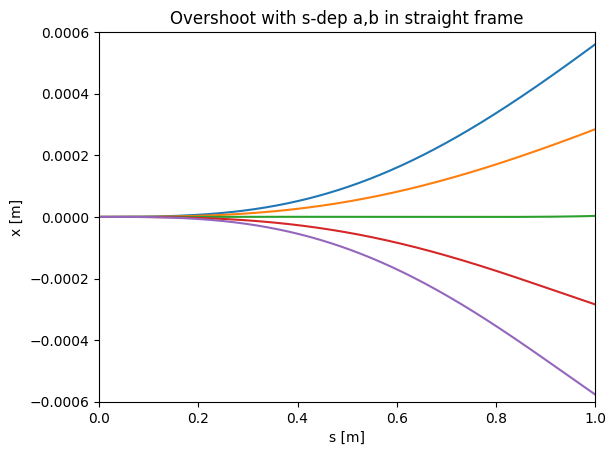

In [ ]:

for sb, sa in zip(sol_strbetter, sol_curved):
    xc = np.sqrt((sb.y[0] + 1/h)**2 + sb.t**2) - 1/h
    sc = np.arctan(sb.t/(sb.y[0] + 1/h)) / h
    xa = sa.y[0]
    deltax = xc - xa[0:len(xc)]#some solutions sometimes have a couple missing points
    plt.plot(sc, deltax)
plt.xlabel('s [m]')   
plt.ylabel('x [m]')
plt.xlim((0.,1.))
plt.ylim((-0.0006,0.0006))
plt.title('Overshoot with s-dep a,b in straight frame')
plt.show()